# Geospatial Analysis

This notebook is used to map the data for geospatial analysis

In [6]:
# imports and setups
import math
from pathlib import Path
import webbrowser

import folium
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data_loader import load_penguin_data, convert_to_gdf

In [28]:
# creating df's
colonies_df = load_penguin_data('MAPPPD_Antarctic_Penguin_Colonies.csv')
adelies_df = load_penguin_data('NOAA_Adelie_Penguin_Telemetry_1997_2013.csv')
occurrences_df = load_penguin_data('OBIS_Penguin_Occurrences_Global.csv')

# creating gdf's
colonies_gdf =  convert_to_gdf(colonies_df, 'longitude_epsg_4326', 'latitude_epsg_4326')
adelies_gdf = convert_to_gdf(adelies_df, 'Longitude', 'Latitude')
occurrences_gdf = convert_to_gdf(occurrences_df)

Since VS-Code didn't output the folium Maps properly, I created a helper function to save the map as file and open it automatically in a browser window

In [29]:
# helper function for saving maps
def save_map(geo_map: folium.Map, path: str) -> None:
    """
    Automatically saves the folium.Map as html file and opens it in the webbrowser.
    
    Args:
        geo_map: The created folium map
        path: The name of the file 
    """
    
    file_path = Path(path).resolve()
    geo_map.save(file_path)
    webbrowser.open(file_path.as_uri())

## Creating a Map

First I want to map the colonies with a heatmap to see the density of penguin colonies

In [16]:
# defining the range for the map to show
c_map_location = [colonies_df['latitude_epsg_4326'].mean(), colonies_df['longitude_epsg_4326'].mean()]

# creating the map
c_map = folium.Map(location=c_map_location, tiles='OpenStreetMap', zoom_start=2)

# adding a heatmap
HeatMap(data=colonies_df[['latitude_epsg_4326', 'longitude_epsg_4326']],radius=10).add_to(c_map) 

# save & display in webbrowser
save_map(c_map, 'c_map.html')

In [17]:
c_map2 = folium.Map(location=c_map_location, tiles='OpenStreetMap', zoom_start=2)

mc = MarkerCluster()

for idx, row in colonies_df.iterrows():
    if not math.isnan(row['longitude_epsg_4326']) and not math.isnan(row['latitude_epsg_4326']):
        mc.add_child(folium.Marker([row['latitude_epsg_4326'], row['longitude_epsg_4326']], popup=f'{row['common_name']}, {row['year']}'))

c_map2.add_child(mc)

save_map(c_map2, 'c_map2.html')

In [18]:
# defining the range for map to show
o_map_locations = [occurrences_df['latitude'].mean(), occurrences_df['longitude'].mean()]

# creating the map
o_map = folium.Map(location=o_map_locations, tiles='OpenStreetMap', zoom_start=3)

# adding a heatmap
HeatMap(data=occurrences_df[['latitude', 'longitude']], radius=10).add_to(o_map)

# save & display in browser
save_map(o_map, 'o_map.html')

In [19]:
# creating the telemetry map
a_map_locations = [adelies_df['Latitude'].mean(), adelies_df['Longitude'].mean()]

# map
a_map = folium.Map(location=a_map_locations, tiles='OpenStreetMap', zoom_start=3)

# adding a markercluster
for idx, row in adelies_df.iterrows(): 
    if not math.isnan(row['Longitude']) and not math.isnan(row['Latitude']):
        mc.add_child(folium.Marker([row['Latitude'], row['Longitude']]))

a_map.add_child(mc)
# save & display 
save_map(a_map, 'a_map.html')

### Trying a new approach: Polar view

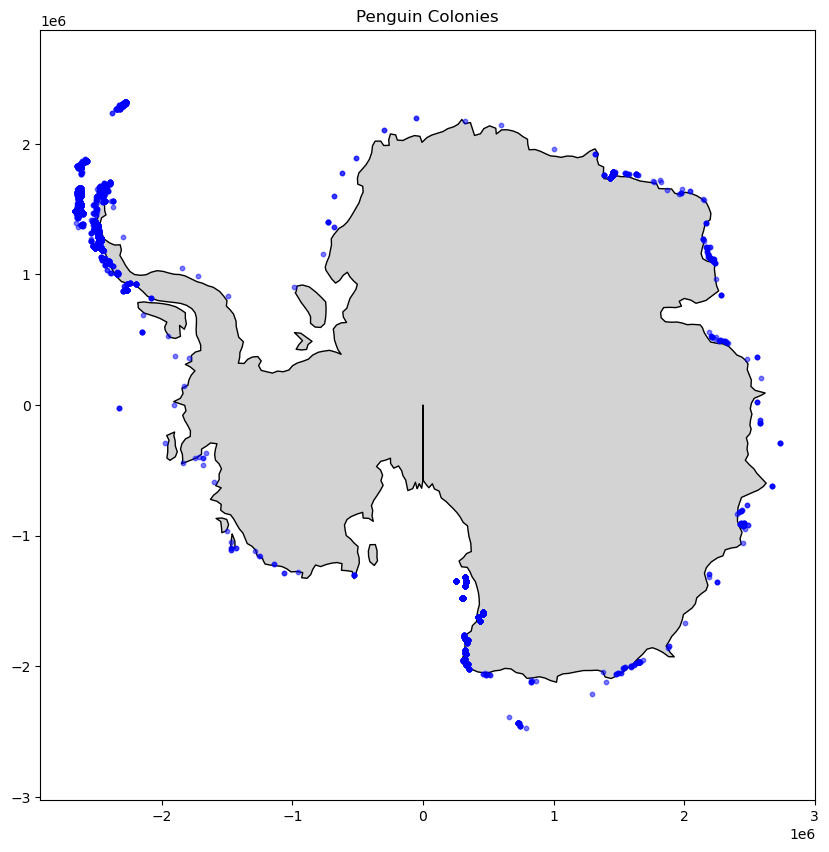

In [22]:
# loading the world map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

antarctica = world[world['ADMIN'] == 'Antarctica']

antarctica_polar = antarctica.to_crs(epsg=3031)

# plotting it with matplotlib
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')

colonies_gdf.plot(ax=ax, markersize=10, color='blue', alpha=0.5)
plt.title('Penguin Colonies')
plt.axis('equal')
plt.show()

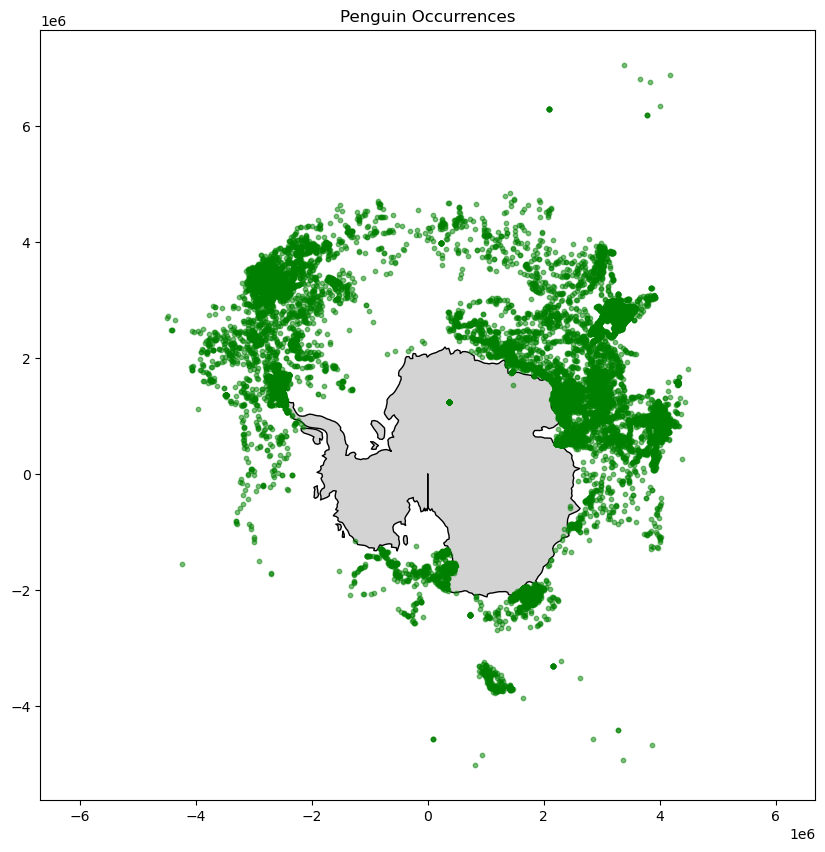

In [24]:
# plotting with matplotlib
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgray', edgecolor='black')
occurrences_gdf.plot(ax=ax, color='green', markersize=10, alpha=0.5)
plt.title('Penguin Occurrences')
plt.axis('equal')
plt.show()

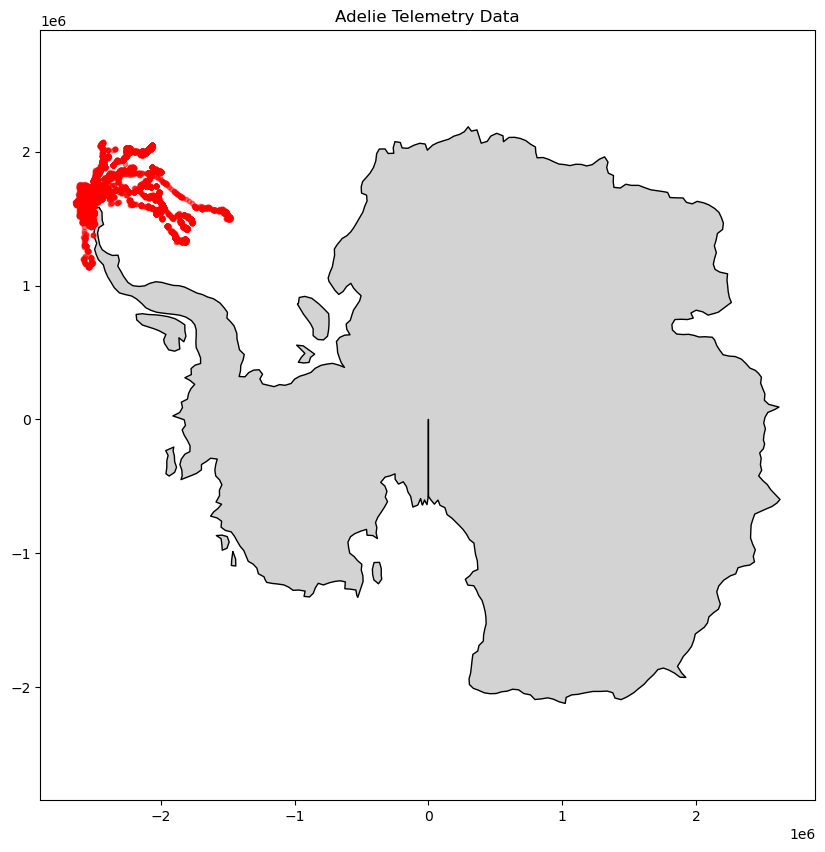

In [26]:
# plotting 
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')
adelies_gdf.plot(ax=ax, color='red', markersize=10, alpha=0.5)

plt.title("Adelie Telemetry Data")
plt.axis('equal')
plt.show()

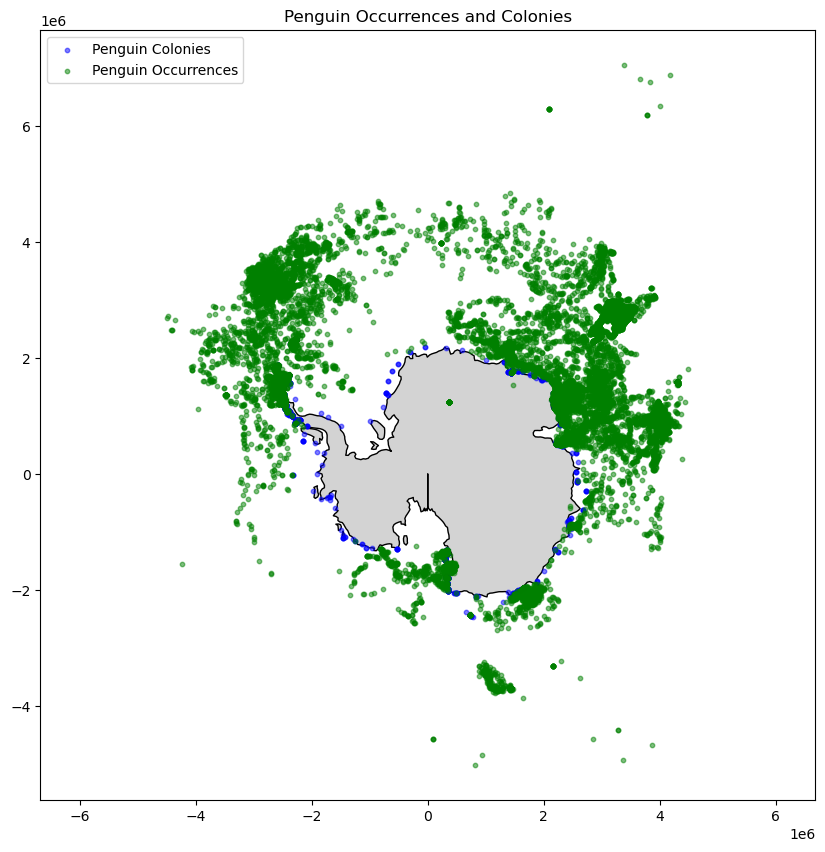

In [27]:
# getting it all together
fig, ax = plt.subplots(figsize=(10,10))

antarctica_polar.plot(ax=ax, color='lightgrey', edgecolor='black')
colonies_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label='Penguin Colonies')
occurrences_gdf.plot(ax=ax, color='green', markersize=10, alpha=0.5, label='Penguin Occurrences')

plt.title('Penguin Occurrences and Colonies')
plt.legend()
plt.axis('equal')
plt.show()